# When in the month to pay in, and the chance of a dip

Someone pays into their holdings every month. The payment is going in whatever
happens. Two questions:

1. **Does waiting for a technical reading get a lower price** than paying on the
   scheduled day? Tried with eight readings (stochastic, RSI, exponential averages,
   fair value gaps, order blocks, the Fibonacci 61.8% level), and with an ensemble of
   four kinds of model that vote.
2. **Can the chance of a dip be forecast?** Not which way the price goes, but how
   likely a close 5% lower is within the next month.

The rules and pass marks were written down before any of this was run
(`docs/DECISIONS.md`, entry 070). The method, in short:

| step | what | why |
|---|---|---|
| pool | 27 markets trained together | about 60,000 days instead of 2,500 for one market |
| scale | returns divided by each market's usual swing | a 2% day means different things in bonds and in coins |
| time order | fit, then a validation year, then a test year, with gaps between | a model must never see days after the one it forecasts |
| planted pattern | made-up answers with a known rule first | a model that cannot find a planted rule cannot be trusted when it finds nothing |
| vote | four different models, each calibrated, averaged | different kinds of model make different mistakes |
| honest comparison | a rule that waits is compared with the same waits on the wrong months | waiting changes the price by itself |
| uncertainty | whole calendar months resampled, all markets together | markets fall on the same days |

Rebuild with `uv run python backend/scripts/build_notebooks.py 15_when_to_pay_in`
(reads `data/research/`; the first run fetches it and needs the keys in `.env`; about
ten minutes).

Left out for too short a record: none
2911 months of 21 trading days in all


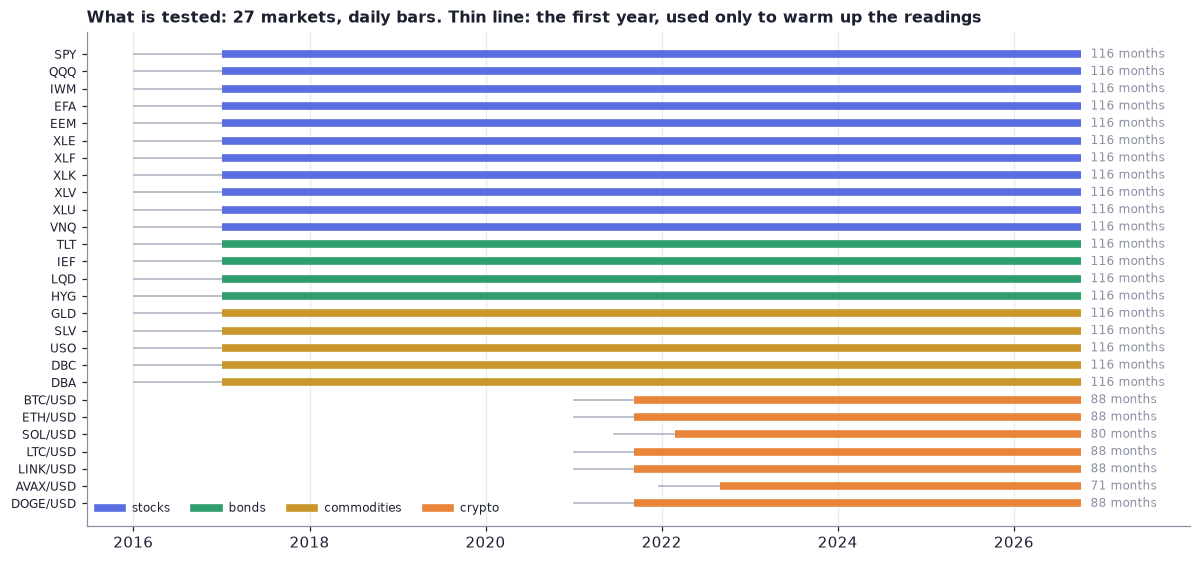

In [1]:
import warnings
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import wilcoxon
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

from radar.analytics import buying, events
from radar.analytics import technical as ta
from radar.config import load_settings
from radar.models import payin
from radar.pipelines import research
from radar.providers.alpaca_rest import AlpacaDataClient
from radar.signals import track
from radar.universe import get_universe

warnings.filterwarnings("ignore")
INK, MUTED, GOOD, BAD, ACCENT = "#1c2030", "#8a8fa3", "#2f9e6e", "#d9534f", "#1f9bb8"
COLOURS = {"stocks": "#5b6ee1", "bonds": "#2f9e6e", "commodities": "#c9972b", "crypto": "#e8853a"}
plt.rcParams.update({
    "figure.figsize": (11, 3.8), "figure.dpi": 110, "font.size": 9.5,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlelocation": "left", "axes.titleweight": "bold", "axes.titlesize": 10.5,
    "axes.edgecolor": MUTED, "text.color": INK, "axes.labelcolor": INK,
    "xtick.color": INK, "ytick.color": INK, "legend.frameon": False,
})
pd.set_option("display.float_format", lambda v: f"{v:.2f}")
pd.set_option("display.width", 240)
pd.set_option("display.max_rows", 120)
GROUPS = {
    "stocks": ["SPY", "QQQ", "IWM", "EFA", "EEM", "XLE", "XLF", "XLK", "XLV", "XLU", "VNQ"],
    "bonds": ["TLT", "IEF", "LQD", "HYG"],
    "commodities": ["GLD", "SLV", "USO", "DBC", "DBA"],
    "crypto": ["BTC/USD", "ETH/USD", "SOL/USD", "LTC/USD", "LINK/USD", "AVAX/USD", "DOGE/USD"],
}
GROUP_OF = {symbol: group for group, symbols in GROUPS.items() for symbol in symbols}
SYMBOLS = list(GROUP_OF)
DATES = sorted({d for kind in events.get_events() for d in kind.dates})
DRAWS = 2000

if [s for s in SYMBOLS if not research.path_of(s).exists()]:
    settings = load_settings()
    with AlpacaDataClient(settings.alpaca_api_key_id, settings.alpaca_api_secret_key) as client:
        bars = research.load(SYMBOLS, client, get_universe().crypto_location)
else:
    bars = research.load(SYMBOLS, None, "")
bars = {s: f for s, f in bars.items() if len(f) >= 750}
print("Left out for too short a record:", [s for s in SYMBOLS if s not in bars] or "none")

M = {}
for symbol, frame in bars.items():
    close = frame["close"].to_numpy(dtype=float)
    starts = buying.month_starts(len(frame), warm_up=ta.WARM_UP)
    M[symbol] = SimpleNamespace(frame=frame, close=close, starts=starts, table=buying.saving_table(close, starts), start_day=pd.DatetimeIndex(frame.index[starts]))

fig, ax = plt.subplots(figsize=(11, 5.2))
for row, symbol in enumerate(reversed(list(M))):
    m = M[symbol]
    ax.plot([m.frame.index[0], m.start_day[0]], [row, row], color=MUTED, lw=1.2, alpha=0.6)
    ax.plot([m.start_day[0], m.frame.index[-1]], [row, row], color=COLOURS[GROUP_OF[symbol]], lw=5, solid_capstyle="butt")
    ax.text(m.frame.index[-1] + pd.Timedelta(days=40), row, f"{len(m.starts)} months", va="center", fontsize=8, color=MUTED)
ax.set_yticks(range(len(M)), list(reversed(list(M))), fontsize=8)
ax.set_xlim(right=pd.Timestamp("2027-12-31"))
ax.grid(axis="y", visible=False)
ax.legend(handles=[plt.Line2D([], [], color=c, lw=5, label=g) for g, c in COLOURS.items()], ncols=4, loc="lower left", fontsize=8)
ax.set(title="What is tested: 27 markets, daily bars. Thin line: the first year, used only to warm up the readings")
fig.tight_layout()
print(f"{sum(len(m.starts) for m in M.values())} months of 21 trading days in all")

## Part A. What there is to gain

Before testing any rule: how much could perfect timing within the month be worth?
For each month, the price on each of its 21 days is compared with the price on day 0,
the scheduled day.

,markets,months,lowest close below day 0 %,average close below day 0 %,last day below day 0 %,day 0 was the lowest %
group,,,,,,
stocks,11,1276,3.22,-0.40,-0.94,18.10
bonds,4,464,1.52,-0.03,-0.29,10.78
commodities,5,580,3.59,-0.48,-1.10,18.10
crypto,7,591,10.16,-0.20,-1.30,10.79


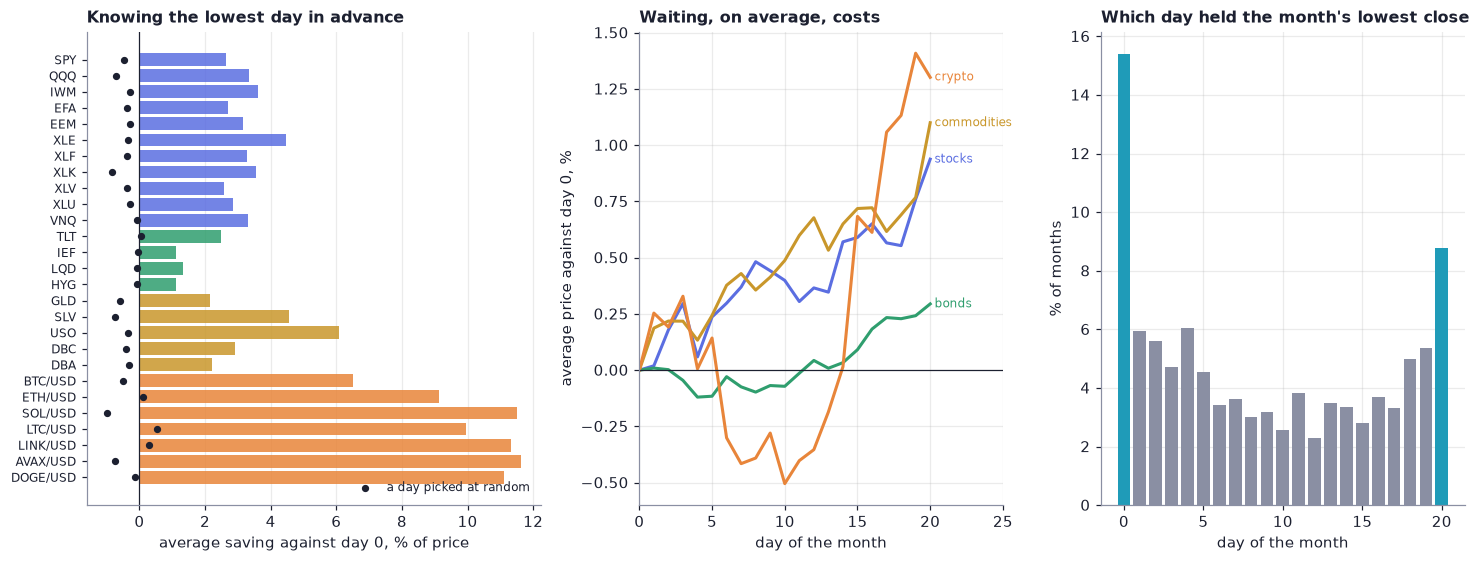

In [2]:
rows = []
for symbol, m in M.items():
    rows.append({"market": symbol, "group": GROUP_OF[symbol], "months": len(m.starts),
                 "lowest close below day 0 %": m.table.max(axis=1).mean() * 100,
                 "average close below day 0 %": m.table.mean(axis=1).mean() * 100,
                 "last day below day 0 %": m.table[:, -1].mean() * 100,
                 "day 0 was the lowest %": (m.table.argmax(axis=1) == 0).mean() * 100})
gain = pd.DataFrame(rows).set_index("market")

fig, axes = plt.subplots(1, 3, figsize=(13.5, 5.2), gridspec_kw={"width_ratios": [1.25, 1, 1]})
ax = axes[0]
order = list(reversed(list(M)))
ax.barh(range(len(order)), gain.loc[order, "lowest close below day 0 %"], color=[COLOURS[GROUP_OF[s]] for s in order], alpha=0.85)
ax.scatter(gain.loc[order, "average close below day 0 %"], range(len(order)), color=INK, s=14, zorder=3, label="a day picked at random")
ax.axvline(0, color=INK, lw=0.8)
ax.set_yticks(range(len(order)), order, fontsize=8)
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right", fontsize=8)
ax.set(title="Knowing the lowest day in advance", xlabel="average saving against day 0, % of price")
ax = axes[1]
for group, symbols in GROUPS.items():
    path = np.mean([-M[s].table.mean(axis=0) * 100 for s in symbols if s in M], axis=0)
    ax.plot(range(buying.EVERY), path, color=COLOURS[group], lw=2, label=group)
    ax.text(buying.EVERY - 0.7, path[-1], group, color=COLOURS[group], fontsize=8, va="center")
ax.axhline(0, color=INK, lw=0.8)
ax.set_xlim(0, buying.EVERY + 4)
ax.set(title="Waiting, on average, costs", xlabel="day of the month", ylabel="average price against day 0, %")
ax = axes[2]
lowest_day = np.concatenate([m.table.argmax(axis=1) for m in M.values()])
share = np.bincount(lowest_day, minlength=buying.EVERY) / len(lowest_day) * 100
ax.bar(range(buying.EVERY), share, color=[ACCENT if d in (0, buying.EVERY - 1) else MUTED for d in range(buying.EVERY)])
ax.set(title="Which day held the month's lowest close", xlabel="day of the month", ylabel="% of months")
fig.tight_layout()
gain.groupby("group").agg(markets=("months", "size"), months=("months", "sum"), **{c: (c, "mean") for c in gain.columns[2:]}).reindex(list(GROUPS))

### What part A shows

- **Perfect timing is worth a few per cent of one payment.** Knowing the month's lowest
  close in advance would have saved 3.2% in stocks, 1.5% in bonds, 3.6% in commodities
  and 10.2% in crypto, on average, once, on that month's payment.
- **A day picked at random costs money.** The average close of the month was 0.4% above
  day 0 in stocks and 0.5% in commodities, and the last day was about 1% above. Prices
  drift upward, so waiting has a price before any rule is tried.
- **Day 0 is the single likeliest day to be the lowest** (15% of months), and the last
  day the next likeliest. That is what a wandering price with an upward lean looks like.

## Part B. Eight readings

Each reading is a yes or no for every day, with settings fixed in advance. The rule:
**pay at the close of the first day in the month the reading is on; if it never is,
pay on the month's last day.** The chart shows what each reading looks like on one
market over the last year.

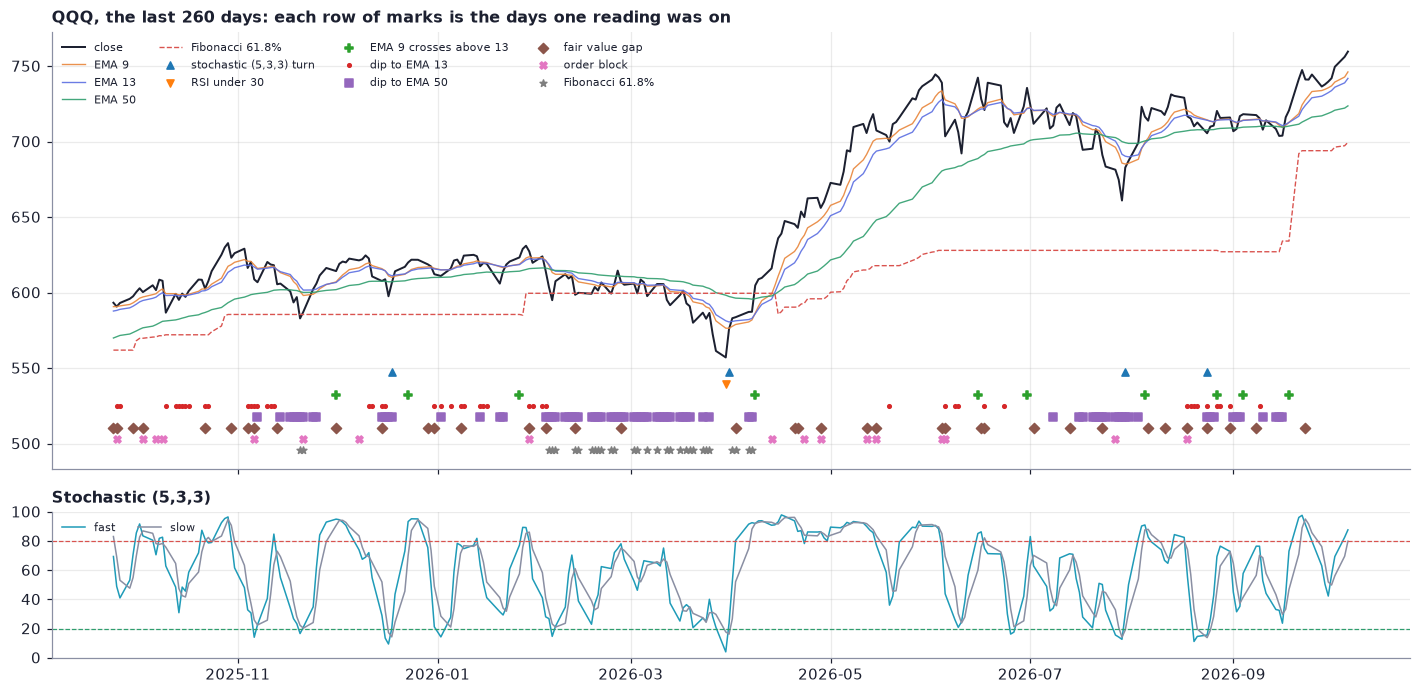

In [3]:
def readings(frame):
    high, low, close = frame["high"], frame["low"], frame["close"]
    return {
        "stochastic (5,3,3) turn": ta.stochastic_cases(high, low, close),
        "RSI under 30": ta.rsi_cases(close, below=True),
        "EMA 9 crosses above 13": ta.ema_cross_cases(close),
        "dip to EMA 13": ta.short_pullback_cases(low, close),
        "dip to EMA 50": ta.trend_pullback_cases(low, close),
        "fair value gap": ta.fair_value_gap_cases(high, low, up=True),
        "order block": ta.order_block_cases(frame, up=True),
        "Fibonacci 61.8%": ta.fibonacci_cases(high, low, close),
    }


PLAIN = "plain: first lower close"
CASES = {symbol: readings(m.frame) for symbol, m in M.items()}
READINGS = list(next(iter(CASES.values())))
ON = {name: {s: ta.flags(M[s].frame.index, CASES[s][name]) for s in M} for name in READINGS}
ON[PLAIN] = {}
for symbol, m in M.items():
    lower = np.zeros(len(m.close), dtype=bool)
    for start in m.starts:
        lower[start : start + buying.EVERY] = m.close[start : start + buying.EVERY] < m.close[start]
    ON[PLAIN][symbol] = lower

EXAMPLE = "QQQ"
shown = M[EXAMPLE].frame.iloc[-260:]
full = M[EXAMPLE].frame
fig, (ax, low_ax) = plt.subplots(2, 1, figsize=(13, 6.4), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
ax.plot(shown.index, shown["close"], color=INK, lw=1.3, label="close")
for span, colour in ((9, "#e8853a"), (13, "#5b6ee1"), (50, "#2f9e6e")):
    ax.plot(shown.index, ta.ema(full["close"], span).loc[shown.index], color=colour, lw=0.9, alpha=0.9, label=f"EMA {span}")
ax.plot(shown.index, ta.fibonacci_level(full["high"], full["low"]).loc[shown.index, "level"], color=BAD, lw=0.9, ls="--", label="Fibonacci 61.8%")
marks = {"stochastic (5,3,3) turn": "^", "RSI under 30": "v", "EMA 9 crosses above 13": "P", "dip to EMA 13": ".", "dip to EMA 50": "s", "fair value gap": "D", "order block": "X", "Fibonacci 61.8%": "*"}
floor = shown["low"].min()
step = (shown["high"].max() - floor) * 0.035
for level, (name, marker) in enumerate(marks.items()):
    days = [d for d in CASES[EXAMPLE][name] if d >= shown.index[0]]
    ax.scatter(days, [floor - (level + 1) * step] * len(days), marker=marker, s=22, color=plt.cm.tab10(level), label=name)
ax.legend(ncols=4, fontsize=7.5, loc="upper left")
ax.set(title=f"{EXAMPLE}, the last 260 days: each row of marks is the days one reading was on")
fast, slow = ta.stochastic(full["high"], full["low"], full["close"])
low_ax.plot(shown.index, fast.loc[shown.index], color=ACCENT, lw=1, label="fast")
low_ax.plot(shown.index, slow.loc[shown.index], color=MUTED, lw=1, label="slow")
low_ax.axhline(20, color=GOOD, lw=0.8, ls="--")
low_ax.axhline(80, color=BAD, lw=0.8, ls="--")
low_ax.legend(ncols=2, fontsize=7.5, loc="upper left")
low_ax.set(title="Stochastic (5,3,3)", ylim=(0, 100))
fig.tight_layout()

In [4]:
def replay(on, months=None, seed=7):
    """Every month's wait and saving under one rule, and the total saving of the same
    waits shuffled between months, pooled over the markets."""
    parts, shuffled = [], np.zeros(DRAWS)
    for i, (symbol, m) in enumerate(M.items()):
        keep = np.ones(len(m.starts), dtype=bool) if months is None else months[symbol]
        if not keep.any():
            continue
        waits = buying.day_paid(on[symbol], m.starts[keep])
        shuffled += buying.shuffled_waits(m.table[keep], waits, draws=DRAWS, seed=seed + i)
        parts.append(pd.DataFrame({"market": symbol, "start": m.start_day[keep], "wait": waits, "saving": buying.savings(m.table[keep], waits)}))
    return pd.concat(parts, ignore_index=True), shuffled


def mean_range(played, seed=7):
    """The plausible range of the average saving, resampling calendar months."""
    keys = payin.month_keys(played["start"].to_numpy())
    months, place = np.unique(keys, return_inverse=True)
    total, count = np.bincount(place, weights=played["saving"]), np.bincount(place)
    picks = np.random.default_rng(seed).integers(0, len(months), size=(DRAWS, len(months)))
    means = total[picks].sum(axis=1) / count[picks].sum(axis=1)
    return np.percentile(means, [2.5, 97.5])


def measure(name, played, shuffled):
    by_market = played.groupby("market")["saving"].mean()
    half = played["start"] < played["start"].sort_values().iloc[len(played) // 2]
    low, high = mean_range(played)
    moved = by_market[by_market != 0]
    return {"reading": name, "months": len(played), "average wait, days": played["wait"].mean(),
            "average saving %": played["saving"].mean() * 100, "range low": low * 100, "range high": high * 100,
            "months cheaper %": (played["saving"] > 0).mean() * 100, "months dearer %": (played["saving"] < 0).mean() * 100,
            "worst month %": played["saving"].min() * 100,
            "markets ahead": int((by_market > 0).sum()), "markets": len(by_market),
            "p across markets": wilcoxon(moved, alternative="greater").pvalue if len(moved) > 5 else 1.0,
            "same waits, wrong months %": shuffled.mean() / len(played) * 100,
            "p against shuffled": float((shuffled >= played["saving"].sum()).mean()),
            "first half %": played.loc[half, "saving"].mean() * 100, "second half %": played.loc[~half, "saving"].mean() * 100}


def verdicts(table, reference):
    """The five conditions of decision 070 for each row of `table`."""
    table = table.copy()
    across = track.survivors([(i, 0, p) for i, p in enumerate(table["p across markets"])], 0.05)
    picked = track.survivors([(i, 0, p) for i, p in enumerate(table["p against shuffled"])], 0.05)
    table["1 saves 0.5%"] = table["average saving %"] >= 0.5
    table["2 across markets"] = [(i, 0) in across and row["markets ahead"] > row["markets"] / 2 for i, row in table.iterrows()]
    table["3 picked the day"] = [(i, 0) in picked for i in table.index]
    table["4 both halves"] = (table["first half %"] > 0) & (table["second half %"] > 0)
    table["5 beats plain"] = table["average saving %"] > reference
    table["passes"] = table[[c for c in table.columns if c[0] in "12345" and c[1] == " "]].all(axis=1)
    return table


PLAYED, SHUFFLED = {}, {}
for name in [*READINGS, PLAIN]:
    PLAYED[name], SHUFFLED[name] = replay(ON[name])
plain = measure(PLAIN, PLAYED[PLAIN], SHUFFLED[PLAIN])
rule_table = verdicts(pd.DataFrame([measure(name, PLAYED[name], SHUFFLED[name]) for name in READINGS]), plain["average saving %"])
pd.concat([rule_table, pd.DataFrame([plain])], ignore_index=True).set_index("reading")[["months", "average wait, days", "average saving %", "range low", "range high", "months cheaper %", "months dearer %", "worst month %", "markets ahead", "same waits, wrong months %", "first half %", "second half %"]]

,months,"average wait, days",average saving %,range low,range high,months cheaper %,months dearer %,worst month %,markets ahead,"same waits, wrong months %",first half %,second half %
reading,,,,,,,,,,,,
"stochastic (5,3,3) turn",2911,15.28,-0.77,-1.56,-0.01,48.13,49.30,-109.13,1,-0.65,-0.25,-1.28
RSI under 30,2911,18.11,-0.82,-1.70,0.01,44.86,52.73,-109.13,1,-0.82,-0.25,-1.39
EMA 9 crosses above 13,2911,14.55,-0.57,-1.25,0.08,37.00,60.05,-100.12,4,-0.61,-0.03,-1.11
dip to EMA 13,2911,8.78,-0.31,-0.84,0.23,37.34,43.22,-100.12,4,-0.33,0.06,-0.68
dip to EMA 50,2911,13.20,-0.71,-1.52,0.04,41.02,42.39,-109.13,1,-0.59,-0.02,-1.41
fair value gap,2911,5.63,-0.21,-0.65,0.23,39.23,46.82,-113.16,7,-0.20,0.24,-0.66
order block,2911,13.18,-0.76,-1.54,-0.01,41.77,53.38,-109.13,2,-0.54,-0.05,-1.47
Fibonacci 61.8%,2911,13.37,-0.77,-1.42,-0.16,37.79,43.80,-100.12,2,-0.59,-0.33,-1.21
plain: first lower close,2911,5.79,-0.34,-0.76,0.06,84.61,15.39,-98.91,7,-0.28,-0.01,-0.66


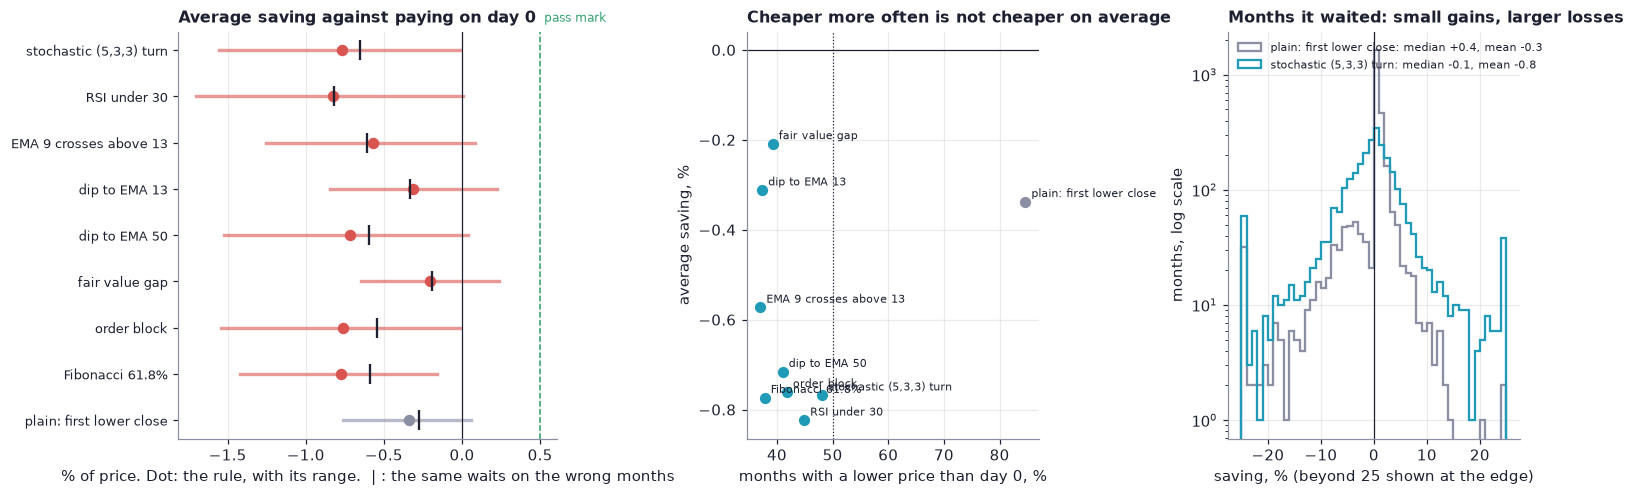

In [5]:
both = pd.concat([rule_table, pd.DataFrame([plain])], ignore_index=True)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), gridspec_kw={"width_ratios": [1.3, 1, 1]})
ax = axes[0]
rows = range(len(both))[::-1]
for row, (_, r) in zip(rows, both.iterrows()):
    colour = MUTED if r["reading"] == PLAIN else (GOOD if r["average saving %"] > 0 else BAD)
    ax.plot([r["range low"], r["range high"]], [row, row], color=colour, lw=2.2, alpha=0.6)
    ax.scatter(r["average saving %"], row, color=colour, s=42, zorder=3)
    ax.scatter(r["same waits, wrong months %"], row, marker="|", color=INK, s=160, zorder=4)
ax.axvline(0, color=INK, lw=0.8)
ax.axvline(0.5, color=GOOD, lw=1, ls="--")
ax.text(0.5, len(both) - 0.45, " pass mark", color=GOOD, fontsize=8, va="bottom")
ax.set_yticks(list(rows), both["reading"], fontsize=8.5)
ax.grid(axis="y", visible=False)
ax.set(title="Average saving against paying on day 0", xlabel="% of price. Dot: the rule, with its range.  | : the same waits on the wrong months")
ax = axes[1]
for _, r in both.iterrows():
    colour = MUTED if r["reading"] == PLAIN else ACCENT
    ax.scatter(r["months cheaper %"], r["average saving %"], color=colour, s=40, zorder=3)
    ax.annotate(r["reading"], (r["months cheaper %"], r["average saving %"]), fontsize=7.2, xytext=(4, 3), textcoords="offset points")
ax.axhline(0, color=INK, lw=0.8)
ax.axvline(50, color=INK, lw=0.8, ls=":")
ax.set(title="Cheaper more often is not cheaper on average", xlabel="months with a lower price than day 0, %", ylabel="average saving, %")
ax = axes[2]
edges = np.linspace(-25, 25, 51)
for name, colour in ((PLAIN, MUTED), ("stochastic (5,3,3) turn", ACCENT)):
    waited = PLAYED[name][PLAYED[name]["wait"] > 0]["saving"] * 100
    ax.hist(waited.clip(-25, 25), bins=edges, histtype="step", color=colour, lw=1.5, label=f"{name}: median {waited.median():+.1f}, mean {waited.mean():+.1f}")
ax.axvline(0, color=INK, lw=0.8)
ax.set_yscale("log")
ax.legend(fontsize=7.5, loc="upper left")
ax.set(title="Months it waited: small gains, larger losses", xlabel="saving, % (beyond 25 shown at the edge)", ylabel="months, log scale")
fig.tight_layout()

,average saving %,markets ahead,p across markets,p against shuffled,1 saves 0.5%,2 across markets,3 picked the day,4 both halves,5 beats plain,passes
reading,,,,,,,,,,
"stochastic (5,3,3) turn",-0.77,1,1.00,0.94,False,False,False,False,False,False
RSI under 30,-0.82,1,1.00,0.52,False,False,False,False,False,False
EMA 9 crosses above 13,-0.57,4,1.00,0.32,False,False,False,False,False,False
dip to EMA 13,-0.31,4,1.00,0.40,False,False,False,False,True,False
dip to EMA 50,-0.71,1,1.00,0.94,False,False,False,False,False,False
fair value gap,-0.21,7,0.99,0.57,False,False,False,False,True,False
order block,-0.76,2,1.00,1.00,False,False,False,False,False,False
Fibonacci 61.8%,-0.77,2,1.00,0.97,False,False,False,False,False,False


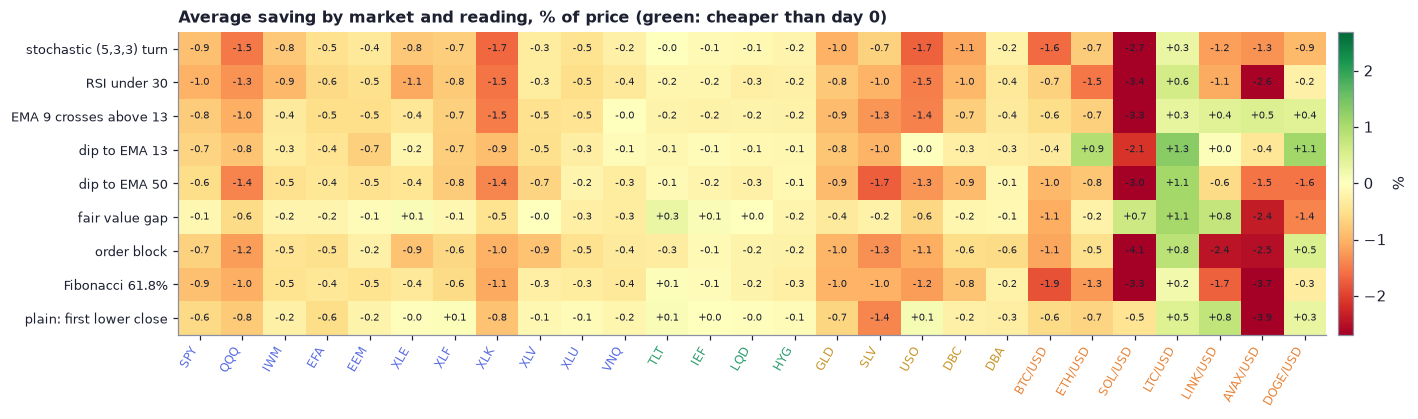

In [6]:
grid = pd.DataFrame({name: PLAYED[name].groupby("market")["saving"].mean() * 100 for name in [*READINGS, PLAIN]}).reindex(list(M))
fig, ax = plt.subplots(figsize=(13, 3.9))
limit = np.nanpercentile(np.abs(grid.to_numpy()), 97)
image = ax.imshow(grid.T.to_numpy(), cmap="RdYlGn", norm=TwoSlopeNorm(0, -limit, limit), aspect="auto")
ax.set_xticks(range(len(grid)), grid.index, rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(len(grid.columns)), grid.columns, fontsize=8.5)
for tick, symbol in zip(ax.get_xticklabels(), grid.index):
    tick.set_color(COLOURS[GROUP_OF[symbol]])
for (row, col), value in np.ndenumerate(grid.T.to_numpy()):
    ax.text(col, row, f"{value:+.1f}", ha="center", va="center", fontsize=6.5, color=INK)
ax.grid(visible=False)
fig.colorbar(image, ax=ax, fraction=0.015, pad=0.01, label="%")
ax.set(title="Average saving by market and reading, % of price (green: cheaper than day 0)")
fig.tight_layout()
rule_table.set_index("reading")[["average saving %", "markets ahead", "p across markets", "p against shuffled", "1 saves 0.5%", "2 across markets", "3 picked the day", "4 both halves", "5 beats plain", "passes"]]

### What part B shows

**No reading passes. Every one of the eight paid more than the scheduled day.**

- Average saving ran from -0.2% (fair value gap) to -0.8% (RSI under 30), over 2,911
  months. All eight are below zero.
- None was ahead in more than 7 of 27 markets.
- **None picked its days.** Put on the wrong months, the same waits did about as well
  (the black ticks sit on the dots). What each reading did is wait, and waiting costs.
- The plain reference, "pay at the first close below day 0", got a lower price in 85% of
  months and still paid 0.3% more on average. That is the trap in this kind of rule:
  many small wins and a few large losses when the price runs away.

The eight readings fail conditions 1 to 4. Two (dip to EMA 13, fair value gap) lose less
than the plain reference, which is the only condition any of them meets.

## The data the models see

Every day of every market becomes one row of 30 inputs, all known at that day's
close. Two answers are attached to each row: was the day cheaper than the rest of its
month (part C), and did a close 5% lower follow within 21 days (part D).

61,510 days with every input; 58,220 with the part C answer; 60,943 with the part D answer


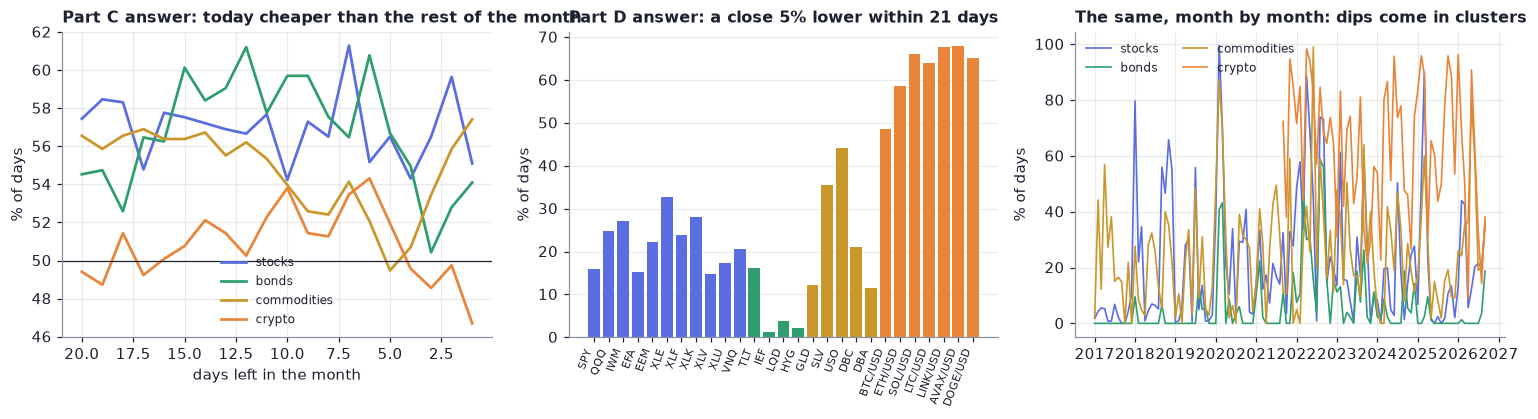

In [7]:
wider = payin.context(bars["SPY"]["close"], bars["TLT"]["close"], bars["HYG"]["close"], bars["IEF"]["close"])
parts = []
for symbol, m in M.items():
    table = payin.inputs(m.frame, DATES, wider, GROUP_OF[symbol])
    table["days_left"] = payin.days_left(len(m.frame), m.starts)
    table["cheaper"] = payin.cheaper_than_rest(m.frame["close"], m.starts).to_numpy()
    dip = payin.dips(m.frame["close"])
    table["dip"] = dip.to_numpy()
    table["own_share"] = payin.own_share_so_far(dip).to_numpy()
    table["market"], table["group"], table["pos"], table["day"] = symbol, GROUP_OF[symbol], np.arange(len(m.frame)), m.frame.index
    parts.append(table.iloc[ta.WARM_UP :])
panel = pd.concat(parts, ignore_index=True).dropna(subset=list(payin.INPUTS)).reset_index(drop=True)
panel["year"] = pd.DatetimeIndex(panel["day"]).year
C_INPUTS, D_INPUTS = [*payin.INPUTS, "days_left"], list(payin.INPUTS)
panel_c = panel.dropna(subset=["cheaper", "days_left"]).reset_index(drop=True)
panel_d = panel.dropna(subset=["dip", "own_share"]).reset_index(drop=True)
print(f"{len(panel):,} days with every input; {len(panel_c):,} with the part C answer; {len(panel_d):,} with the part D answer")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.9))
ax = axes[0]
for group in GROUPS:
    rate = panel_c[panel_c["group"] == group].groupby("days_left")["cheaper"].mean() * 100
    ax.plot(rate.index, rate, color=COLOURS[group], lw=1.8, label=group)
ax.axhline(50, color=INK, lw=0.8)
ax.invert_xaxis()
ax.legend(fontsize=8)
ax.set(title="Part C answer: today cheaper than the rest of the month", xlabel="days left in the month", ylabel="% of days")
ax = axes[1]
rate = panel_d.groupby("market")["dip"].mean().reindex(list(M)) * 100
ax.bar(range(len(rate)), rate, color=[COLOURS[GROUP_OF[s]] for s in rate.index])
ax.set_xticks(range(len(rate)), rate.index, rotation=70, ha="right", fontsize=7)
ax.grid(axis="x", visible=False)
ax.set(title="Part D answer: a close 5% lower within 21 days", ylabel="% of days")
ax = axes[2]
monthly = panel_d.assign(month=pd.DatetimeIndex(panel_d["day"]).to_period("M").to_timestamp()).groupby(["group", "month"])["dip"].mean().unstack(0) * 100
for group in GROUPS:
    ax.plot(monthly.index, monthly[group], color=COLOURS[group], lw=1.1, label=group)
ax.legend(fontsize=8, ncols=2)
ax.set(title="The same, month by month: dips come in clusters", ylabel="% of days")
fig.tight_layout()

,today cheaper than the rest of the month,a 5% dip within 21 days
0,"stocks_swing_20: +0.089, same sign in 8 of 10 ...","swing_20: +0.329, same sign in 10 of 10 years"
1,"stocks_ret_20: -0.044, same sign in 8 of 10 years","day_range: +0.108, same sign in 9 of 10 years"
2,"ret_60: -0.025, same sign in 7 of 10 years","from_ema_200: -0.067, same sign in 8 of 10 years"
3,"from_fib: -0.022, same sign in 6 of 10 years","stocks_swing_20: -0.065, same sign in 8 of 10 ..."
4,"since_block: +0.021, same sign in 6 of 10 years","since_gap: +0.060, same sign in 7 of 10 years"
5,"from_ema_50: -0.019, same sign in 7 of 10 years","from_high_60: -0.053, same sign in 5 of 10 years"


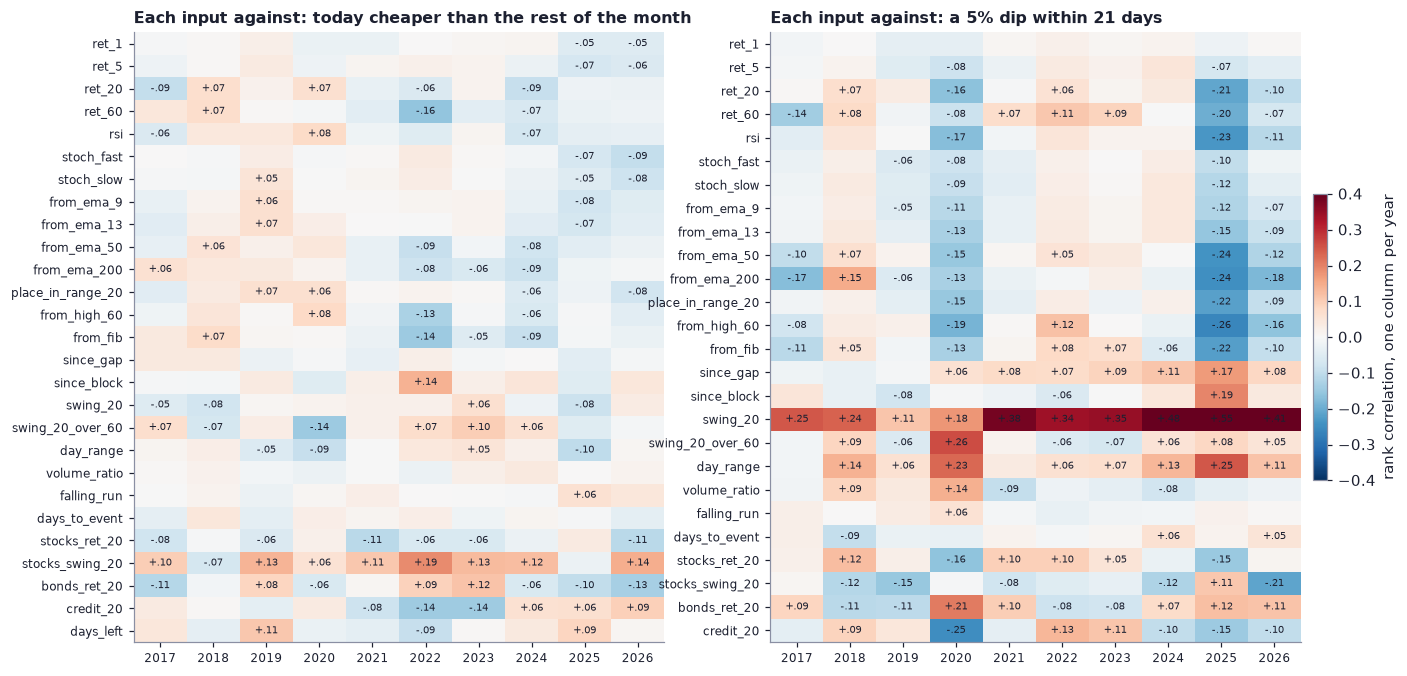

In [8]:
def by_year_link(table, answer, columns):
    """Rank correlation of each input with the answer, year by year."""
    return pd.DataFrame({year: part[columns].corrwith(part[answer], method="spearman") for year, part in table.groupby("year")})


SHOWN = [c for c in C_INPUTS if not c.startswith("is_")]
links = {"today cheaper than the rest of the month": by_year_link(panel_c, "cheaper", SHOWN),
         "a 5% dip within 21 days": by_year_link(panel_d, "dip", SHOWN[:-1])}
fig, axes = plt.subplots(1, 2, figsize=(14, 7.2))
for ax, (title, link) in zip(axes, links.items()):
    image = ax.imshow(link.to_numpy(), cmap="RdBu_r", vmin=-0.4, vmax=0.4, aspect="auto")
    ax.set_xticks(range(link.shape[1]), link.columns, fontsize=8)
    ax.set_yticks(range(link.shape[0]), link.index, fontsize=8)
    for (row, col), value in np.ndenumerate(link.to_numpy()):
        if abs(value) >= 0.05:
            ax.text(col, row, f"{value:+.2f}".replace("0.", "."), ha="center", va="center", fontsize=6.3, color=INK)
    ax.grid(visible=False)
    ax.set(title=f"Each input against: {title}")
fig.colorbar(image, ax=axes, fraction=0.012, pad=0.01, label="rank correlation, one column per year")
strongest = {}
for title, link in links.items():
    average = link.mean(axis=1)
    same_sign = np.sign(link).eq(np.sign(average), axis=0).sum(axis=1)
    top = average.abs().sort_values(ascending=False).head(6).index
    strongest[title] = [f"{name}: {average[name]:+.3f}, same sign in {same_sign[name]} of {link.shape[1]} years" for name in top]
pd.DataFrame(strongest)

### What the inputs show before any model is fitted

- **For "is today cheaper than the rest of the month", no input has a link worth the
  name.** The strongest, the stock market's recent swing, has a rank correlation of
  +0.09, and the sign is not even the same every year.
- **For "a 5% dip within 21 days", one input stands out and holds every year:** the
  market's own 20-day swing, at +0.33 in 10 of 10 years. Rough markets dip more. The
  other inputs add little beside it.
- Dips come in clusters in time, and differ enormously between groups: almost never in
  bond funds, most of the time in coins. A forecast must first know which market it is
  looking at.

## Part C. The ensemble on "is today cheaper than the rest of the month?"

Four models: a logistic regression, a random forest, boosted trees and a small neural
network. For each test year from 2020 they are fitted on earlier years, calibrated on
a validation year, and then asked about the test year. Their chances are averaged.

**First the planted pattern.** The real answers are replaced with made-up ones that
follow a known rule (70% "yes" when the stochastic is low and the last 20 days fell,
45% otherwise). A model that knew the rule would be right a known share of the time;
the chart shows how much of that each model recovers.

In [9]:
MEMBERS = ["logistic", "forest", "boosted", "network", "vote"]
FOLD_YEARS = (2020, 2026)


def run(table, columns, answer):
    """Out-of-sample chances for every test year, and each year's validation rows with
    the vote's chances on them."""
    x, y, days = table[columns].to_numpy(), table[answer].to_numpy(), table["day"].to_numpy()
    out = {name: np.full(len(table), np.nan) for name in MEMBERS}
    validation = {}
    for fold in payin.by_year(days, *FOLD_YEARS):
        vote = payin.fit_vote(x[fold.fit], y[fold.fit], x[fold.validation], y[fold.validation])
        for name, chance in vote.chances(x[fold.test]).items():
            out[name][fold.test] = chance
        validation[fold.year] = (fold.validation, vote.chances(x[fold.validation])["vote"])
        last = vote
    return pd.DataFrame(out), validation, last


panel_c["planted"] = payin.planted_answers(panel_c, seed=11)
planted, _, _ = run(panel_c, C_INPUTS, "planted")
tested = planted["vote"].notna().to_numpy()
truth = payin.planted_chance(panel_c)
rows = []
for year, part in panel_c[tested].groupby("year"):
    answers = part["planted"].to_numpy()
    usual = max(answers.mean(), 1 - answers.mean())
    knowing = ((truth[part.index] > 0.5) == (answers == 1)).mean()
    row = {"year": year, "days": len(part), "always the commoner answer %": usual * 100, "knowing the rule %": knowing * 100}
    for name in MEMBERS:
        right = ((planted.loc[part.index, name] > 0.5) == (answers == 1)).mean()
        row[name] = (right - usual) / (knowing - usual) * 100
    rows.append(row)
planted_table = pd.DataFrame(rows).set_index("year")
planted_table

,days,always the commoner answer %,knowing the rule %,logistic,forest,boosted,network,vote
year,,,,,,,,
2020,4820,50.48,55.46,38.33,85.83,80.42,58.75,77.08
2021,5340,52.10,56.54,35.44,80.17,83.97,67.09,73.84
2022,6936,51.56,57.55,63.22,89.90,94.47,74.52,84.13
2023,7189,51.72,58.30,38.48,79.92,75.90,68.08,74.00
2024,7243,51.46,57.12,59.27,87.07,97.32,84.63,84.15
2025,7194,51.92,57.52,41.19,86.60,86.60,69.23,78.41
2026,5118,50.39,56.51,64.86,92.01,96.17,82.43,91.37


,test days,right %,always the commoner answer %,"ahead by, points",share of resamples not ahead,ranking score (0.5 is none)
model,,,,,,
logistic,43840,52.32,54.26,-1.93,0.97,0.50
forest,43840,53.54,54.26,-0.72,0.78,0.50
boosted,43840,52.69,54.26,-1.56,0.92,0.49
network,43840,53.19,54.26,-1.06,1.00,0.50
vote,43840,53.47,54.26,-0.79,0.80,0.49


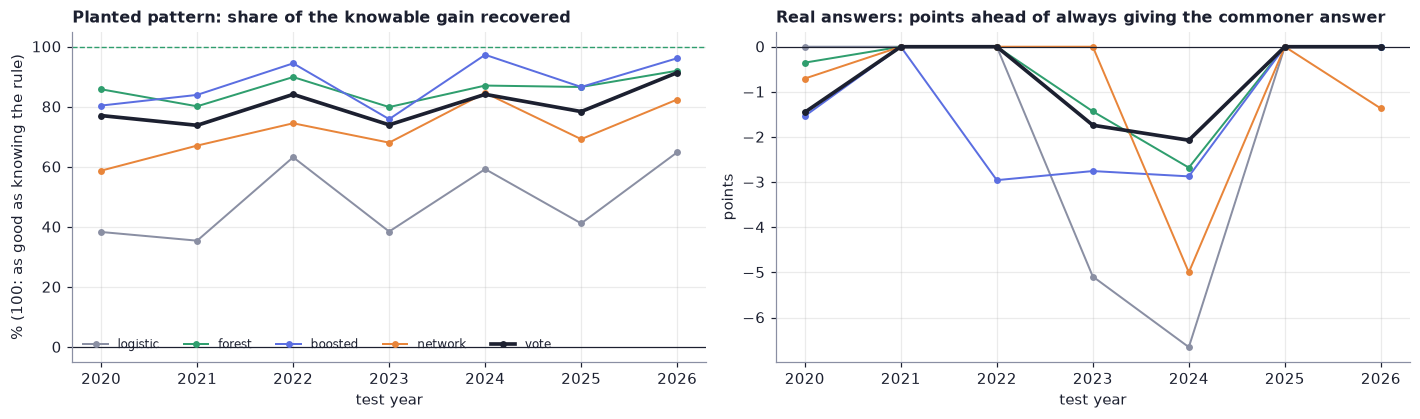

In [10]:
c_chances, c_validation, _ = run(panel_c, C_INPUTS, "cheaper")
test_c = panel_c[c_chances["vote"].notna()]
answers = test_c["cheaper"].to_numpy()
keys = payin.month_keys(test_c["day"].to_numpy())
commoner = float(answers.mean() >= 0.5)
base_wrong = (answers != commoner).astype(float)
rows = []
for name in MEMBERS:
    chance = c_chances.loc[test_c.index, name].to_numpy()
    wrong = ((chance > 0.5) != (answers == 1)).astype(float)
    _, p_value = payin.resampled_gain(keys, wrong, base_wrong, draws=DRAWS)
    rows.append({"model": name, "test days": len(test_c), "right %": (1 - wrong.mean()) * 100, "always the commoner answer %": (1 - base_wrong.mean()) * 100,
                 "ahead by, points": (base_wrong.mean() - wrong.mean()) * 100, "share of resamples not ahead": p_value, "ranking score (0.5 is none)": roc_auc_score(answers, chance)})
c_accuracy = pd.DataFrame(rows).set_index("model")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.9))
shades = {"logistic": "#8a8fa3", "forest": "#2f9e6e", "boosted": "#5b6ee1", "network": "#e8853a", "vote": INK}
ax = axes[0]
for name in MEMBERS:
    ax.plot(planted_table.index, planted_table[name], color=shades[name], lw=2.4 if name == "vote" else 1.3, marker="o", ms=3.5, label=name)
ax.axhline(100, color=GOOD, lw=0.9, ls="--")
ax.axhline(0, color=INK, lw=0.8)
ax.legend(fontsize=8, ncols=5, loc="lower left")
ax.set(title="Planted pattern: share of the knowable gain recovered", ylabel="% (100: as good as knowing the rule)", xlabel="test year")
ax = axes[1]
for name in MEMBERS:
    chance = c_chances.loc[test_c.index, name].to_numpy()
    ahead = pd.Series(((chance > 0.5) == (answers == 1)).astype(float) - (answers == commoner).astype(float), index=test_c["year"].to_numpy()).groupby(level=0).mean() * 100
    ax.plot(ahead.index, ahead, color=shades[name], lw=2.4 if name == "vote" else 1.3, marker="o", ms=3.5, label=name)
ax.axhline(0, color=INK, lw=0.8)
ax.set(title="Real answers: points ahead of always giving the commoner answer", ylabel="points", xlabel="test year")
fig.tight_layout()
c_accuracy

**Then the rule itself:** pay on the first day the vote's chance is above a
threshold. The threshold for each test year is the one that saved most in that
year's validation months. It is judged on the test years by the same five conditions
as the readings, against the plain reference over the same months.

           validation months  over 0.50  over 0.55  over 0.60  over 0.65  over 0.70  chosen
test year                                                                                  
2020                     220      -0.01      -0.15      -0.64      -0.21      -0.76    0.50
2021                     220       0.00       0.00       0.30       0.17       0.17    0.60
2022                     235       0.00       0.00      -1.01      -2.05      -2.05    0.50
2023                     322       0.96       2.46       1.91       1.91       1.91    0.55
2024                     332      -0.11      -2.00      -2.00      -2.00      -2.00    0.50
2025                     334       0.00       0.00      -2.41      -2.57      -2.57    0.50
2026                     338       0.00      -0.16      -0.38      -0.38      -0.38    0.50


reading,"the vote, threshold chosen on validation",plain: first lower close
months,2191,2191
"average wait, days",5.97,5.81
average saving %,-0.62,-0.39
range low,-1.29,-0.90
range high,0.00,0.13
months cheaper %,14.79,84.85
months dearer %,20.26,15.15
worst month %,-100.12,-98.91
markets ahead,2,7
markets,27,27


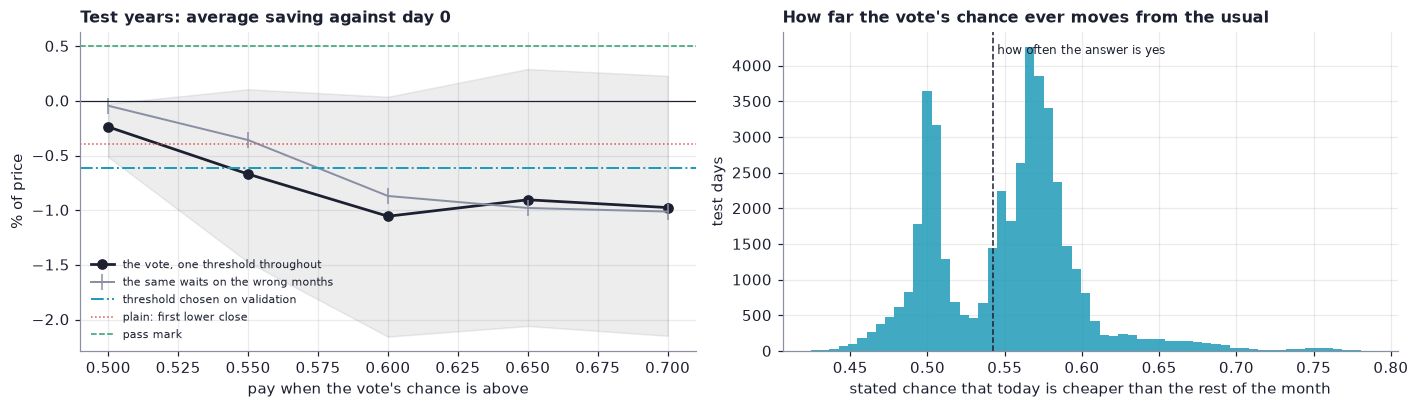

In [11]:
def on_from(table, rows, chance, threshold):
    on = {symbol: np.zeros(len(m.close), dtype=bool) for symbol, m in M.items()}
    part = table.iloc[rows]
    for symbol, group in part.assign(over=chance > threshold).groupby("market"):
        on[symbol][group["pos"].to_numpy()] = group["over"].to_numpy()
    return on


def months_inside(table, rows):
    """Months whose first and second-to-last days are both among `rows`."""
    part, keep = table.iloc[rows], {}
    for symbol, m in M.items():
        inside = np.zeros(len(m.close), dtype=bool)
        inside[part.loc[part["market"] == symbol, "pos"].to_numpy()] = True
        keep[symbol] = inside[m.starts] & inside[m.starts + buying.EVERY - 2]
    return keep


rows, chosen = [], {}
for year, (validation_rows, chance) in c_validation.items():
    keep = months_inside(panel_c, validation_rows)
    saved = {t: replay(on_from(panel_c, validation_rows, chance, t), keep)[0]["saving"].mean() * 100 for t in payin.THRESHOLDS}
    chosen[year] = max(saved, key=saved.get)
    rows.append({"test year": year, "validation months": int(sum(k.sum() for k in keep.values())), **{f"over {t:.2f}": v for t, v in saved.items()}, "chosen": chosen[year]})
threshold_table = pd.DataFrame(rows).set_index("test year")

test_rows = np.flatnonzero(c_chances["vote"].notna().to_numpy())
vote_chance = c_chances["vote"].to_numpy()[test_rows]
TEST_MONTHS = {symbol: np.asarray(m.start_day >= pd.Timestamp(f"{FOLD_YEARS[0]}-01-01")) for symbol, m in M.items()}
own_threshold = panel_c["year"].map(chosen).to_numpy()[test_rows]
played_vote, shuffled_vote = replay(on_from(panel_c, test_rows, vote_chance, own_threshold), TEST_MONTHS)
played_plain, shuffled_plain = replay(ON[PLAIN], TEST_MONTHS)
plain_test = measure(PLAIN, played_plain, shuffled_plain)
vote_table = verdicts(pd.DataFrame([measure("the vote, threshold chosen on validation", played_vote, shuffled_vote)]), plain_test["average saving %"])
fixed = []
for t in payin.THRESHOLDS:
    played, shuffled = replay(on_from(panel_c, test_rows, vote_chance, t), TEST_MONTHS)
    fixed.append(measure(f"over {t:.2f}", played, shuffled))
fixed = pd.DataFrame(fixed)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
ax = axes[0]
ax.plot(payin.THRESHOLDS, fixed["average saving %"], color=INK, lw=1.8, marker="o", label="the vote, one threshold throughout")
ax.plot(payin.THRESHOLDS, fixed["same waits, wrong months %"], color=MUTED, lw=1.3, marker="|", ms=10, label="the same waits on the wrong months")
ax.fill_between(payin.THRESHOLDS, fixed["range low"], fixed["range high"], color=INK, alpha=0.08)
ax.axhline(vote_table["average saving %"].iloc[0], color=ACCENT, lw=1.3, ls="-.", label="threshold chosen on validation")
ax.axhline(plain_test["average saving %"], color=BAD, lw=1, ls=":", label="plain: first lower close")
ax.axhline(0.5, color=GOOD, lw=1, ls="--", label="pass mark")
ax.axhline(0, color=INK, lw=0.8)
ax.legend(fontsize=7.5)
ax.set(title="Test years: average saving against day 0", xlabel="pay when the vote's chance is above", ylabel="% of price")
ax = axes[1]
ax.hist(vote_chance, bins=60, color=ACCENT, alpha=0.85)
ax.axvline(answers.mean(), color=INK, lw=1, ls="--")
ax.text(answers.mean(), ax.get_ylim()[1] * 0.93, " how often the answer is yes", fontsize=8)
ax.set(title="How far the vote's chance ever moves from the usual", xlabel="stated chance that today is cheaper than the rest of the month", ylabel="test days")
fig.tight_layout()
print(threshold_table.to_string())
pd.concat([vote_table, pd.DataFrame([plain_test])], ignore_index=True).set_index("reading").T

### What part C shows

**The models can learn. There is nothing here for them to learn.**

- On the planted pattern the vote recovered 74% to 91% of what knowing the rule would
  give, in every test year. The forest and the boosted trees did best (76% to 97%); the
  network managed 59% to 85%; the logistic regression 35% to 65%, as expected for a rule
  that needs two inputs at once.
- On the real answers no model beat always giving the commoner answer: the vote was
  right on 53.5% of 43,840 test days against 54.3%. Its ranking score was 0.49, where
  0.50 is no skill.
- The vote's stated chance barely moves from the usual (right-hand chart), so the
  threshold chosen on validation was 0.50 in five years of seven: "pay on day 0".
- **The rule does not pass.** Over 2,191 test months it paid 0.6% more than day 0, was
  ahead in 2 of 27 markets, and did worse than its own waits on the wrong months.

## Part D. The chance of a dip

The same models, inputs and time order, with a different answer: **does a close at
least 5% below today's follow within 21 trading days?** A forecast here is a stated
chance, so it is scored by the **Brier score** (the average squared gap between the
chance stated and what happened; lower is better) and by whether the stated chances
were true to what happened.

Two baselines to beat:

- **the market's own share so far**: how often this market has dipped like that,
  counting only days whose month has already passed;
- **the swing alone**: a logistic regression on the 20-day swing and the market's
  group. If the ensemble cannot beat one number, the one number is what to use.

In [12]:
d_chances, _, last_vote = run(panel_d, D_INPUTS, "dip")
SIMPLE = ["swing_20", *(f"is_{g}" for g in payin.GROUPS)]
simple = np.full(len(panel_d), np.nan)
xs = panel_d[SIMPLE].to_numpy().copy()
xs[:, 0] = np.log(xs[:, 0])
ys, d_days = panel_d["dip"].to_numpy(), panel_d["day"].to_numpy()
for fold in payin.by_year(d_days, *FOLD_YEARS):
    known = np.concatenate([fold.fit, fold.validation])
    simple[fold.test] = LogisticRegression(C=1.0, max_iter=1000).fit(xs[known], ys[known]).predict_proba(xs[fold.test])[:, 1]

test_d = panel_d[d_chances["vote"].notna()]
happened = test_d["dip"].to_numpy()
d_keys = payin.month_keys(test_d["day"].to_numpy())
STATED = {"own share so far": test_d["own_share"].to_numpy(), "swing alone": simple[test_d.index], **{name: d_chances.loc[test_d.index, name].to_numpy() for name in MEMBERS}}
LOSS = {name: (chance - happened) ** 2 for name, chance in STATED.items()}
rows = []
for name, chance in STATED.items():
    gain_own, p_own = payin.resampled_gain(d_keys, LOSS[name], LOSS["own share so far"], draws=DRAWS)
    gain_swing, p_swing = payin.resampled_gain(d_keys, LOSS[name], LOSS["swing alone"], draws=DRAWS)
    bands = payin.reliability(chance, happened)
    judged = bands[bands["days"] >= 200]
    rows.append({"forecast": name, "test days": len(happened), "Brier score": LOSS[name].mean(), "ranking score": roc_auc_score(happened, chance),
                 "better than own share %": gain_own * 100, "resamples with no gain": p_own,
                 "better than swing alone %": gain_swing * 100, "resamples with no gain ": p_swing,
                 "widest gap, stated to happened, points": (judged["stated"] - judged["happened"]).abs().max() * 100, "true to its chances": payin.calibrated(bands)})
d_table = pd.DataFrame(rows).set_index("forecast")
print(f"A 5% dip followed on {happened.mean() * 100:.1f}% of {len(happened):,} test days")
d_table

A 5% dip followed on 32.9% of 45,863 test days


,test days,Brier score,ranking score,better than own share %,resamples with no gain,better than swing alone %,resamples with no gain,"widest gap, stated to happened, points",true to its chances
forecast,,,,,,,,,
own share so far,45863,0.18,0.75,0.00,1.00,0.03,0.49,14.31,False
swing alone,45863,0.18,0.75,-0.03,0.51,0.00,1.00,9.47,False
logistic,45863,0.21,0.66,-12.67,1.00,-12.63,1.00,12.74,False
forest,45863,0.20,0.69,-9.74,1.00,-9.71,1.00,8.37,False
boosted,45863,0.21,0.67,-13.13,1.00,-13.09,1.00,29.51,False
network,45863,0.21,0.65,-15.27,1.00,-15.24,1.00,12.54,False
vote,45863,0.20,0.68,-10.50,1.00,-10.46,1.00,13.83,False


,from,to,days,stated,happened,"gap, points"
0,0.00,0.10,3804,0.06,0.11,-4.74
1,0.10,0.20,11177,0.16,0.21,-5.41
2,0.20,0.30,10526,0.25,0.27,-2.20
3,0.30,0.40,6480,0.34,0.37,-2.47
4,0.40,0.50,5236,0.45,0.44,1.30
5,0.50,0.60,5389,0.55,0.54,0.44
6,0.60,0.70,2519,0.64,0.58,6.39
7,0.70,0.80,709,0.73,0.60,13.83
8,0.80,0.90,23,0.81,0.70,11.68


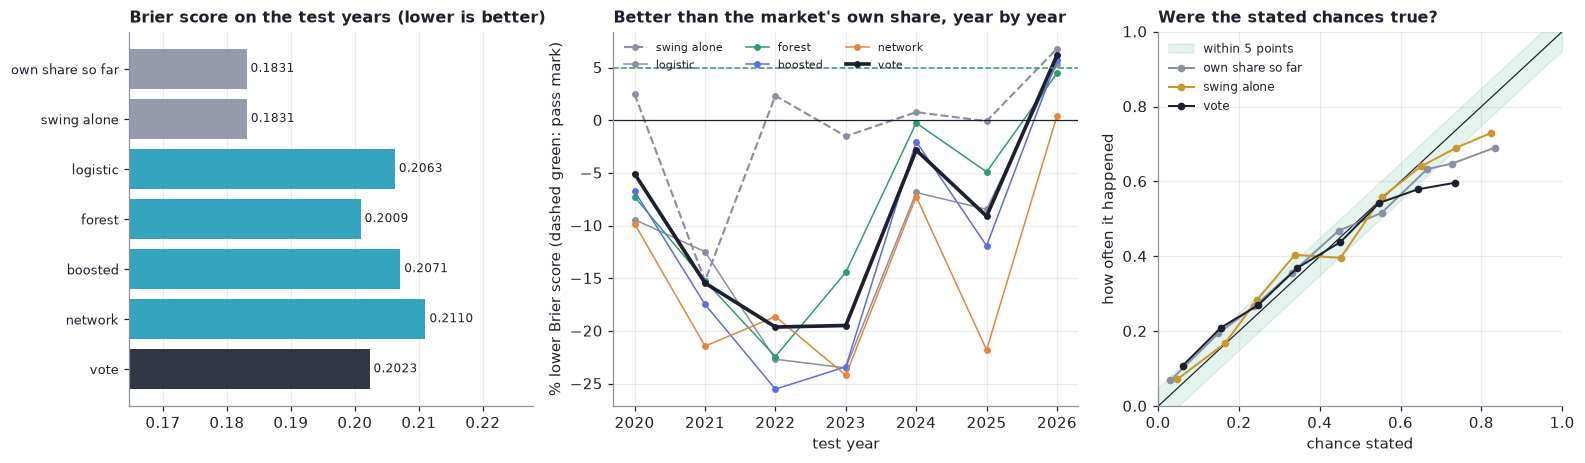

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.3), gridspec_kw={"width_ratios": [1, 1.15, 1]})
ax = axes[0]
names = list(STATED)[::-1]
ax.barh(range(len(names)), [LOSS[n].mean() for n in names], color=[INK if n == "vote" else (MUTED if n in ("own share so far", "swing alone") else ACCENT) for n in names], alpha=0.9)
for row, name in enumerate(names):
    ax.text(LOSS[name].mean(), row, f" {LOSS[name].mean():.4f}", va="center", fontsize=8)
ax.set_yticks(range(len(names)), names, fontsize=8.5)
ax.set_xlim(min(v.mean() for v in LOSS.values()) * 0.9, max(v.mean() for v in LOSS.values()) * 1.08)
ax.grid(axis="y", visible=False)
ax.set(title="Brier score on the test years (lower is better)")
ax = axes[1]
years = test_d["year"].to_numpy()
for name, colour, width in (("swing alone", MUTED, 1.4), ("logistic", "#8a8fa3", 1), ("forest", "#2f9e6e", 1), ("boosted", "#5b6ee1", 1), ("network", "#e8853a", 1), ("vote", INK, 2.4)):
    skill = pd.Series(LOSS[name], index=years).groupby(level=0).sum() / pd.Series(LOSS["own share so far"], index=years).groupby(level=0).sum()
    ax.plot(skill.index, (1 - skill) * 100, color=colour, lw=width, marker="o", ms=3.5, ls="--" if name == "swing alone" else "-", label=name)
ax.axhline(0, color=INK, lw=0.8)
ax.axhline(5, color=GOOD, lw=1, ls="--")
ax.legend(fontsize=7.5, ncols=3)
ax.set(title="Better than the market's own share, year by year", ylabel="% lower Brier score (dashed green: pass mark)", xlabel="test year")
ax = axes[2]
ax.plot([0, 1], [0, 1], color=INK, lw=0.8)
ax.fill_between([0, 1], [-0.05, 0.95], [0.05, 1.05], color=GOOD, alpha=0.12, label="within 5 points")
for name, colour in (("own share so far", MUTED), ("swing alone", "#c9972b"), ("vote", INK)):
    bands = payin.reliability(STATED[name], happened)
    bands = bands[bands["days"] >= 200]
    ax.plot(bands["stated"], bands["happened"], color=colour, lw=1.3, marker="o", ms=4, label=name)
ax.legend(fontsize=8, loc="upper left")
ax.set(title="Were the stated chances true?", xlabel="chance stated", ylabel="how often it happened", xlim=(0, 1), ylim=(0, 1))
fig.tight_layout()
payin.reliability(STATED["vote"], happened).assign(**{"gap, points": lambda t: (t["stated"] - t["happened"]) * 100})

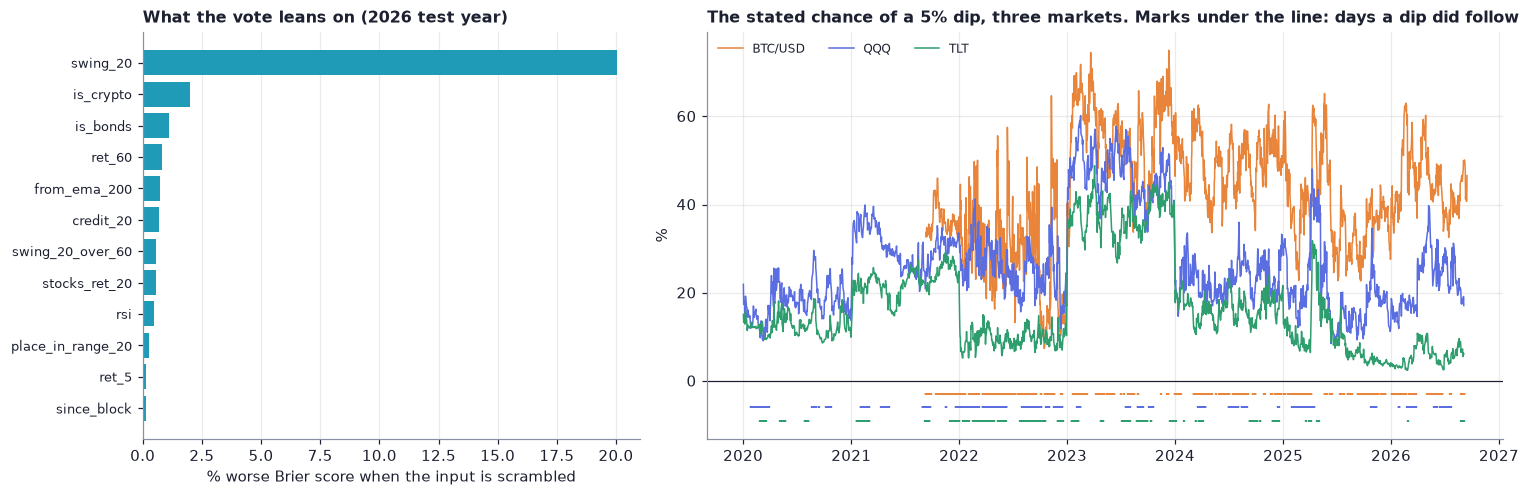

In [14]:
last_year = panel_d["year"].to_numpy() == FOLD_YEARS[1]
x_last, y_last = panel_d.loc[last_year, D_INPUTS].to_numpy(), panel_d.loc[last_year, "dip"].to_numpy()
base_loss = payin.brier(last_vote.chances(x_last)["vote"], y_last)
rng = np.random.default_rng(3)
importance = {}
for col, name in enumerate(D_INPUTS):
    worse = []
    for _ in range(3):
        mixed = x_last.copy()
        mixed[:, col] = rng.permutation(mixed[:, col])
        worse.append(payin.brier(last_vote.chances(mixed)["vote"], y_last) - base_loss)
    importance[name] = np.mean(worse) / base_loss * 100
importance = pd.Series(importance).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [1, 1.6]})
ax = axes[0]
top = importance.tail(12)
ax.barh(range(len(top)), top, color=ACCENT)
ax.set_yticks(range(len(top)), top.index, fontsize=8.5)
ax.grid(axis="y", visible=False)
ax.set(title=f"What the vote leans on ({FOLD_YEARS[1]} test year)", xlabel="% worse Brier score when the input is scrambled")
ax = axes[1]
for symbol, colour in (("BTC/USD", COLOURS["crypto"]), ("QQQ", COLOURS["stocks"]), ("TLT", COLOURS["bonds"])):
    part = test_d[test_d["market"] == symbol]
    ax.plot(part["day"], d_chances.loc[part.index, "vote"] * 100, color=colour, lw=1, label=symbol)
    dipped = part[part["dip"] == 1]
    ax.scatter(dipped["day"], np.full(len(dipped), {"BTC/USD": -3, "QQQ": -6, "TLT": -9}[symbol]), color=colour, s=2, marker="|")
ax.axhline(0, color=INK, lw=0.8)
ax.legend(fontsize=8, ncols=3, loc="upper left")
ax.set(title="The stated chance of a 5% dip, three markets. Marks under the line: days a dip did follow", ylabel="%")
fig.tight_layout()

### What part D shows

**As designed, the ensemble fails, and so does every forecast tried.**

- A 5% dip followed on 32.9% of 45,863 test days.
- The vote's Brier score was 0.20 against 0.18 for the market's own share so far: about
  10% worse, where the pass mark was 5% better. Its ranking score was 0.68 against 0.75.
- The swing alone matched the market's own share and did not beat it.
- No forecast was true to its chances: the widest gaps between stated and happened were
  14 points (own share), 9 (swing alone) and 14 (the vote).

**Why, and it is a fault in the design, not a property of markets.** Two things were
wrong with what I wrote down in decision 070:

1. The models were not given the market's own share so far, which is the very thing the
   baseline uses. A coin and a bond fund were to be told apart from the swing and the
   group label alone.
2. Each test year's models stopped learning more than a year before it (a validation
   year plus two gaps), and coins enter the record in 2022. For the 2022 and 2023 test
   years the models had seen no coin at all.

The chart of what the vote leans on confirms the first point: it leans on the swing and
little else. This part is to be redone once, with those two faults fixed and the change
written down first, as the app's large-fall forecast.

## The result, and my guesses checked

| part | result |
|---|---|
| A. what there is to gain | perfect timing: 1.5% to 10% of one payment; a random day costs about 0.4% |
| B. eight readings | 0 of 8 pass; all eight paid more than the scheduled day |
| C. the ensemble on the same question | found the planted pattern; did not pass on real answers |
| D. the chance of a dip | failed as designed; the design was at fault |

**Guesses (decision 070).** Right on B and C. Wrong on D: I expected the ensemble to
beat the market's own share, and it lost to it.

## What this means

**Pay in on the scheduled day.** Waiting for the stochastic, the RSI, an average, a fair
value gap, an order block or a Fibonacci level got a worse price on average, in every
group of markets, and so did four kinds of model voting together. This is what theory
says should happen when the next move cannot be told: no rule for choosing the day beats
the first day, and waiting gives up the drift.

**These readings still have a use.** They describe where a price stands, and they can be
the condition of a stop or a take-profit rule the user chooses, which is judged on the
worst case it avoids, not on the average price.

**Limits.** Ten years for funds, five for coins, and mostly rising markets, which is
when waiting costs most. Closes only: a reading that fires within the day was acted on
at that day's close. The same 27 markets were used in notebooks 13 and 14, so they are
not fresh evidence.